# Milestone 3 — Stage 2: Snell refraction helper

Evidence notebook for **M3 Stage 2**: synthetic `refract_direction` checks, then entry refraction on the bear mesh.

Plan: [`plans/milestone_03/03_face_transport_plan.md`](../../plans/milestone_03/03_face_transport_plan.md). Previous: `03_0_ray_sampling_basics.ipynb`. Next: `03_2_refraction.ipynb`.


In [7]:
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

!pip install --quiet --no-cache-dir "{ROOT}[dev]" -c "{ROOT}/requirements.txt"

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [8]:
import numpy as np

from gummybear.geometry import inspect_stl
from gummybear.optics import (
    OpticalMaterialConfig,
    PointLightConfig,
    SourceSamplingParams,
    make_source_ray_bundle,
    refract_direction,
)
from gummybear.rays import first_visible_hits
from gummybear_validation.helpers import print_entry_refraction_summary
from gummybear_validation.plotting import plot_entry_internal_directions_3d


In [9]:
def _unit(v):
    v = np.asarray(v, dtype=float)
    return v / np.linalg.norm(v)

normal = _unit([0.0, 0.0, 1.0])

# Normal incidence: air → n=1.33
t, ok = refract_direction(_unit([0.0, 0.0, -1.0]), normal, n_from=1.0, n_to=1.33)
print("normal incidence ok:", ok, "t:", t, "norm:", np.linalg.norm(t))

# Oblique incidence
t2, ok2 = refract_direction(_unit([0.5, 0.0, -1.0]), normal, n_from=1.0, n_to=1.33)
print("oblique ok:", ok2, "t:", t2)


normal incidence ok: True t: [ 0.  0. -1.] norm: 1.0
oblique ok: True t: [ 0.33625082  0.         -0.94177247]


In [10]:
inspection = inspect_stl(ROOT / "cad" / "proto_bear.stl")
mesh = inspection["mesh"]

light = PointLightConfig(position=(0.0, 0.0, 20.0), intensity=100.0)
sampling = SourceSamplingParams(mode="point_uniform", n_rays=4096)
source_rays = make_source_ray_bundle(light, mesh_bbox=mesh.bounds, sampling=sampling)

source_valid, source_depth, source_entry_faces = first_visible_hits(mesh, source_rays)
material = OpticalMaterialConfig(n_refractive=1.33)


In [11]:
from gummybear.optics import refract_directions

active = source_valid & (source_entry_faces >= 0)
entry_dirs = source_rays.directions[active]
entry_normals = np.asarray(mesh.face_normals)[source_entry_faces[active]]

transmitted, ok = refract_directions(
    entry_dirs,
    entry_normals,
    n_from=1.0,
    n_to=material.n_refractive,
)

internal_dirs = np.zeros_like(source_rays.directions)
internal_valid = np.zeros(source_rays.n_rays, dtype=bool)
internal_dirs[active] = transmitted
internal_valid[active] = ok

print_entry_refraction_summary(
    source_rays,
    source_valid,
    source_entry_faces,
    internal_dirs,
    internal_valid,
    mesh,
)


source entry hits: 3523
internal valid: 3523
fraction refracted: 1.0000
internal direction norm min/max/mean: 1.000000 1.000000 1.000000
bend angle deg min/mean/max: 0.05 8.33 40.75
dot(internal, entry_normal) mean: -0.9194
fraction pointing inward: 1.0000


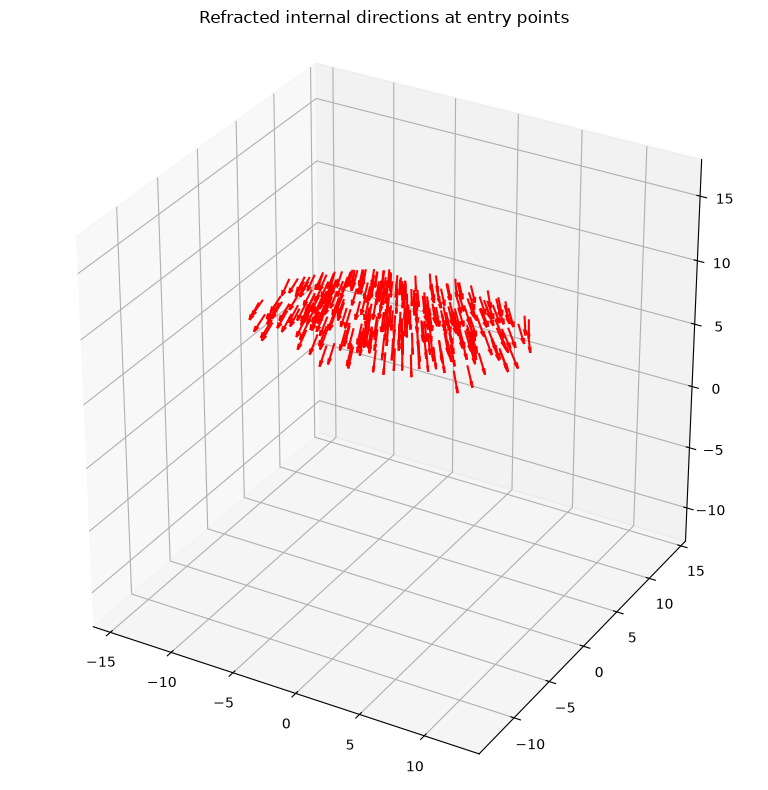

In [12]:
entry_points = source_rays.origins + source_depth[:, None] * source_rays.directions
entry_points[~source_valid] = np.nan

plot_entry_internal_directions_3d(
    mesh,
    entry_points,
    internal_dirs,
    internal_valid,
)
